
--- Processing AAPL ---
Saved AAPL_historical.csv

--- Processing MSFT ---
Saved MSFT_historical.csv


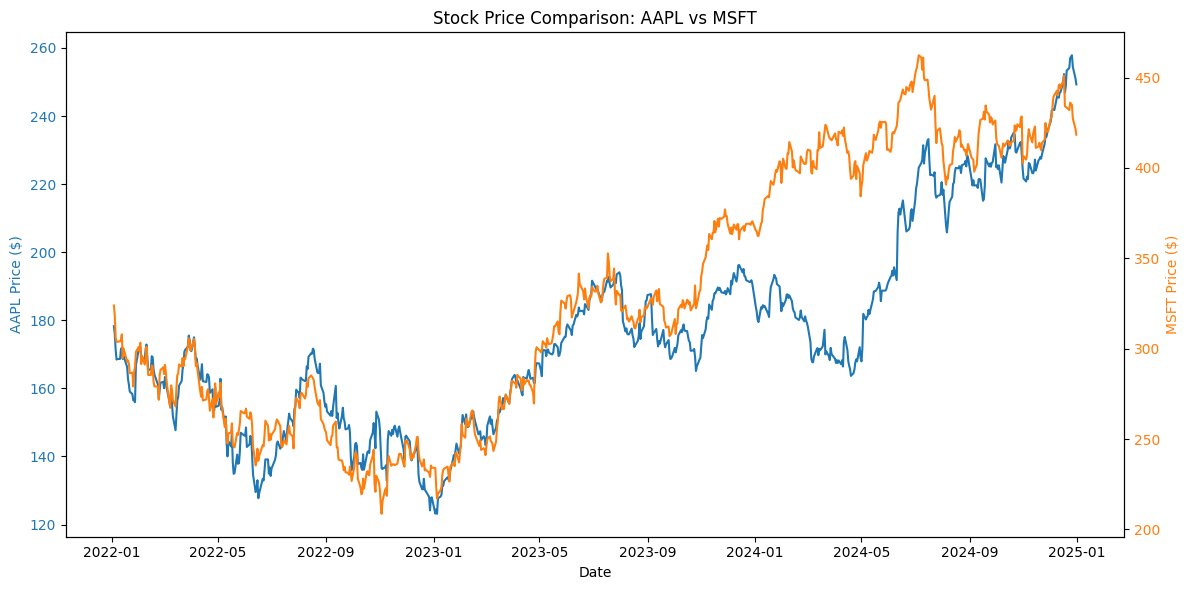

In [23]:
# ==========================================
# 1. IMPORTS & CONFIGURATION
# ==========================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Modeling Imports
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from utils import ForecastingMetrics # Ensure utils.py is in the folder

# Global Settings
FORECAST_DAYS = 60
START_DATE = '2022-01-01'
END_DATE = '2025-01-01'
INITIAL_LAGS = 5 # Default, will be visually checked in Cell 2

# ==========================================
# 2. USER DATA FUNCTIONS
# ==========================================
def get_and_clean_stock_data(ticker_symbol, save_csv=True):
    print(f"\n--- Processing {ticker_symbol} ---")
    
    # 1. Ingestion
    df = yf.download(ticker_symbol, start=START_DATE, end=END_DATE, progress=False)
    
    if df.empty:
        raise ValueError(f"No data found for {ticker_symbol}.")

    # 2. Flatten MultiIndex if necessary
    if isinstance(df.columns, pd.MultiIndex):
        try:
            if 'Close' in df.columns.get_level_values(0):
                df = df.xs('Close', axis=1, level=0, drop_level=True)
            elif 'Close' in df.columns.get_level_values(1):
                df = df.xs('Close', axis=1, level=1, drop_level=True)
        except KeyError:
            pass
            
    if 'Close' in df.columns:
        data = df[['Close']].copy()
    else:
        data = df.iloc[:, 0].to_frame(name='Close')

    # 3. Handling Missing/Outliers
    if data.isnull().values.any():
        print(f"Found {data.isnull().sum()} missing values. Filling...")
        data = data.ffill().bfill()
        
    # 4. Save to CSV (Requirement)
    if save_csv:
        filename = f"{ticker_symbol}_historical.csv"
        data.to_csv(filename)
        print(f"Saved {filename}")
    
    return data

def plot_two_stocks(data1, name1, data2, name2):
    fig, ax1 = plt.subplots(figsize=(12, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Date')
    ax1.set_ylabel(f'{name1} Price ($)', color=color)
    ax1.plot(data1.index, data1['Close'], color=color, label=name1)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  
    color = 'tab:orange'
    ax2.set_ylabel(f'{name2} Price ($)', color=color)
    ax2.plot(data2.index, data2['Close'], color=color, label=name2)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Stock Price Comparison: {name1} vs {name2}')
    fig.tight_layout()
    plt.show()

# ==========================================
# 3. INITIALIZATION
# ==========================================
MY_STOCKS = ['AAPL', 'MSFT'] 
stock_data_store = {}

for ticker in MY_STOCKS:
    stock_data_store[ticker] = get_and_clean_stock_data(ticker)

plot_two_stocks(
    stock_data_store[MY_STOCKS[0]], MY_STOCKS[0],
    stock_data_store[MY_STOCKS[1]], MY_STOCKS[1]
)


 PROCESSING: AAPL
  > Training ARIMA(1,1,1)...
  > Training Linear Regression...
  > Training Random Forest...
  > Validating on Test Set...
  > Scores (MSE): {'ARIMA': 308.3264616025803, 'LinReg': 568.0975924635649, 'RF': 331.2251576505582}
  > WINNER: ARIMA


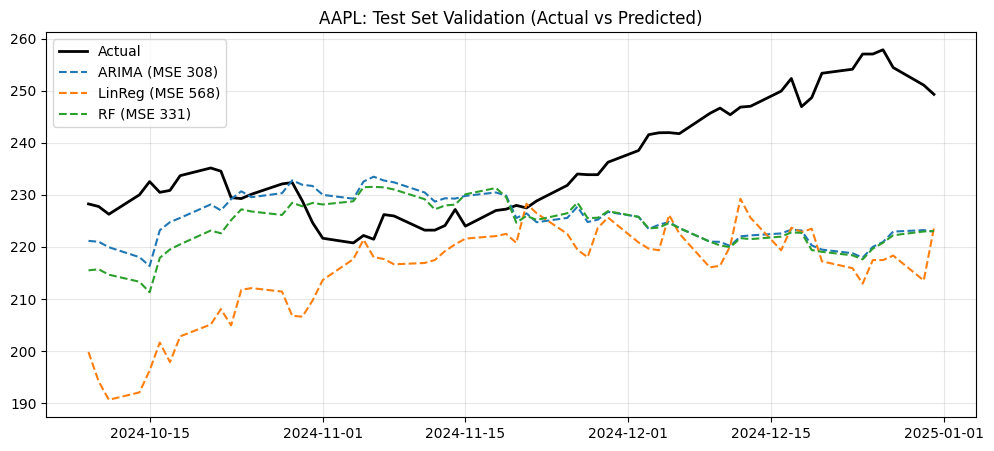

  > Generating 60-Day Future Forecast with ARIMA...


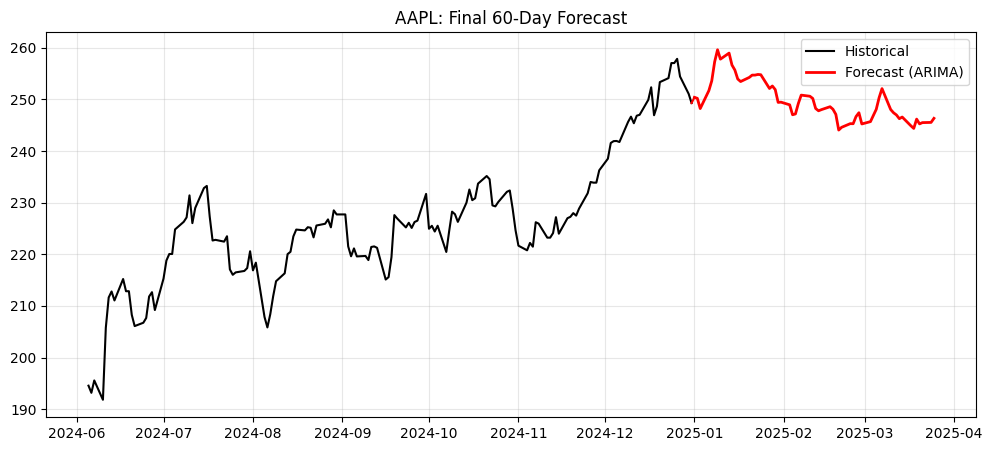


 PROCESSING: MSFT
  > Training ARIMA(1,1,1)...
  > Training Linear Regression...
  > Training Random Forest...
  > Validating on Test Set...
  > Scores (MSE): {'ARIMA': 345.5904707581102, 'LinReg': 237.03101483141342, 'RF': 190.6679920679802}
  > WINNER: RF


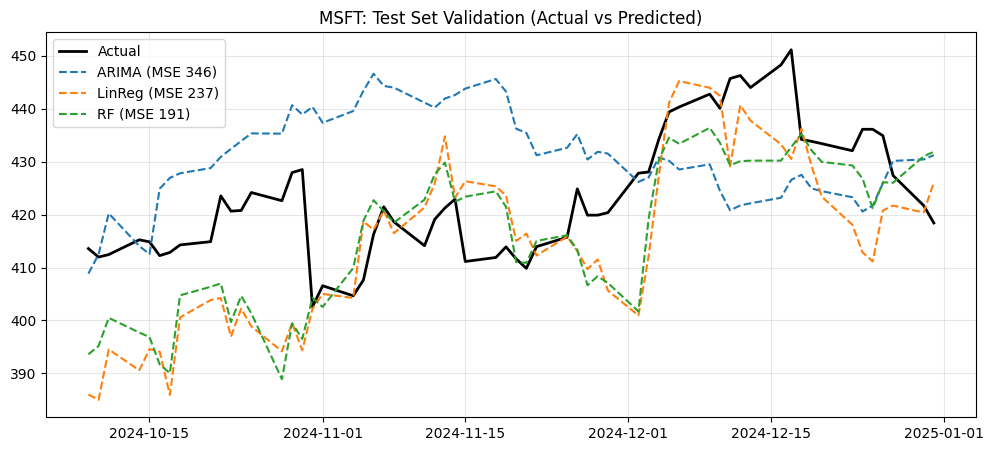

  > Generating 60-Day Future Forecast with RF...


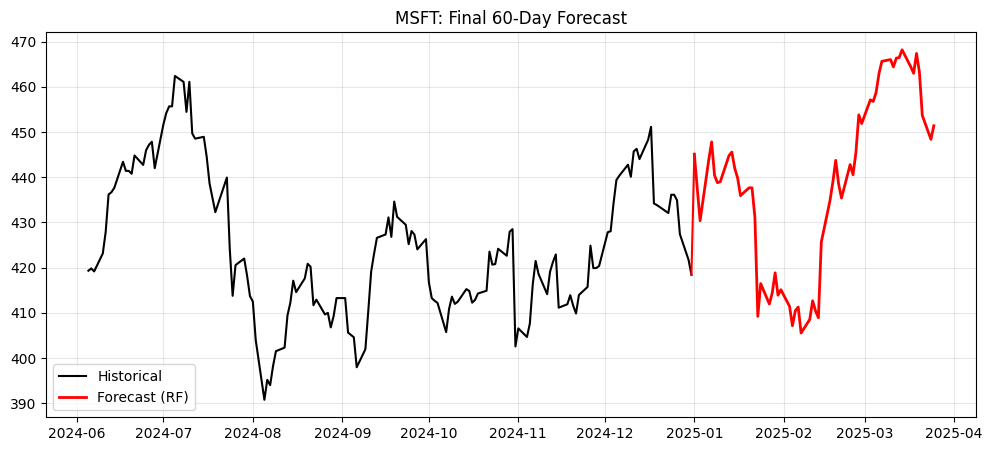

In [25]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. CONFIGURATION
# ==========================================
MY_STOCKS = ['AAPL', 'MSFT']
START_DATE = '2022-01-01'
END_DATE = '2025-01-01'
FORECAST_DAYS = 60
SEASONAL_PERIOD = 252 # Trading days/year
LAGS = 60 # As per your old attempt

# --- HELPERS ---

def get_data(ticker):
    print(f"\n{'='*40}\n PROCESSING: {ticker}\n{'='*40}")
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df = df.xs(ticker, axis=1, level=1)
    df = df.asfreq('B').ffill()
    return df[['Close']]

def make_lagged(series, nlags):
    """Creates X (features) and y (target) for ML models."""
    s = pd.Series(series).reset_index(drop=True)
    df = pd.DataFrame({'y': s})
    for i in range(1, nlags+1):
        df[f'lag_{i}'] = s.shift(i)
    return df.dropna()

def recursive_forecast(last_window, model, steps, feature_names):
    """ recursively predicts future values for ML models."""
    preds = []
    current_window = list(last_window) # Should be size NLAGS
    
    for _ in range(steps):
        # Create input row (1, n_features)
        input_df = pd.DataFrame([current_window], columns=feature_names)
        pred = model.predict(input_df)[0]
        preds.append(pred)
        
        # Update window: drop oldest, add new prediction
        current_window.pop(0)
        current_window.append(pred)
        
    return np.array(preds)

def run_full_pipeline(ticker):
    # 1. Load Data
    df = get_data(ticker)
    series = df['Close']
    
    # 2. Decompose (Additive as per your request)
    # Close = Trend + Seasonal + Resid
    # SA (Seasonally Adjusted) = Close - Seasonal = Trend + Resid
    decomp = seasonal_decompose(series, model='additive', period=SEASONAL_PERIOD)
    seasonal_component = decomp.seasonal
    sa_series = series - seasonal_component
    
    # 3. Train/Test Split (Last 60 Days)
    TEST_SIZE = 60
    split_idx = len(sa_series) - TEST_SIZE
    
    # ARIMA Data (Series based)
    train_sa = sa_series.iloc[:split_idx]
    test_sa = sa_series.iloc[split_idx:]
    
    # ML Data (Feature based)
    df_lagged = make_lagged(sa_series, LAGS)
    X = df_lagged.drop(columns='y')
    y = df_lagged['y']
    
    # Align ML split with ARIMA split
    # Note: df_lagged index starts at LAGS, so we adjust the split
    train_size = split_idx - LAGS 
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:train_size+TEST_SIZE]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:train_size+TEST_SIZE]
    
    # Seasonal Component for Test Period
    test_seasonal = seasonal_component.iloc[split_idx:]

    # 4. Train Models
    print("  > Training ARIMA(1,1,1)...")
    arima = ARIMA(train_sa, order=(1,1,1)).fit()
    
    print("  > Training Linear Regression...")
    lr = LinearRegression().fit(X_train, y_train)
    
    print("  > Training Random Forest...")
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42).fit(X_train, y_train)
    
    # 5. Internal Test (Forecast & Reconstruct)
    print("  > Validating on Test Set...")
    
    # A. ARIMA
    pred_sa_arima = arima.forecast(steps=TEST_SIZE)
    final_arima = pred_sa_arima.values + test_seasonal.values
    
    # B. ML (Recursive)
    feature_names = X_train.columns.tolist()
    # Initial window is the last 'LAGS' values of the TRAINING set
    last_window_train = train_sa.iloc[-LAGS:].values 
    
    pred_sa_lr = recursive_forecast(last_window_train, lr, TEST_SIZE, feature_names)
    final_lr = pred_sa_lr + test_seasonal.values
    
    pred_sa_rf = recursive_forecast(last_window_train, rf, TEST_SIZE, feature_names)
    final_rf = pred_sa_rf + test_seasonal.values
    
    # C. Evaluate
    actual_test = series.iloc[split_idx:].values
    scores = {
        'ARIMA': mean_squared_error(actual_test, final_arima),
        'LinReg': mean_squared_error(actual_test, final_lr),
        'RF': mean_squared_error(actual_test, final_rf)
    }
    winner = min(scores, key=scores.get)
    print(f"  > Scores (MSE): {scores}")
    print(f"  > WINNER: {winner}")
    
    # PLOT 1: TEST SET VALIDATION
    plt.figure(figsize=(12, 5))
    plt.plot(df.index[-TEST_SIZE:], actual_test, label='Actual', color='black', linewidth=2)
    plt.plot(df.index[-TEST_SIZE:], final_arima, label=f'ARIMA (MSE {scores["ARIMA"]:.0f})', linestyle='--')
    plt.plot(df.index[-TEST_SIZE:], final_lr, label=f'LinReg (MSE {scores["LinReg"]:.0f})', linestyle='--')
    plt.plot(df.index[-TEST_SIZE:], final_rf, label=f'RF (MSE {scores["RF"]:.0f})', linestyle='--')
    plt.title(f"{ticker}: Test Set Validation (Actual vs Predicted)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 6. Future Forecast
    print(f"  > Generating 60-Day Future Forecast with {winner}...")
    
    # A. Future Seasonality (Tile last year)
    last_year_season = seasonal_component.iloc[-SEASONAL_PERIOD:].values
    future_seasonal = np.tile(last_year_season, 2)[:FORECAST_DAYS]
    
    # B. Refit & Forecast Winner
    future_sa = []
    
    if winner == 'ARIMA':
        full_arima = ARIMA(sa_series, order=(1,1,1)).fit()
        future_sa = full_arima.forecast(steps=FORECAST_DAYS).values
    else:
        # Refit ML
        model = lr if winner == 'LinReg' else rf
        model.fit(X, y) # Fit on ALL available lag data
        # Forecast from very last known window
        last_window_full = sa_series.iloc[-LAGS:].values
        future_sa = recursive_forecast(last_window_full, model, FORECAST_DAYS, feature_names)
        
    # C. Reconstruct
    future_prices = future_sa + future_seasonal
    
    # D. Save
    future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=FORECAST_DAYS, freq='B')
    df_forecast = pd.DataFrame({'Date': future_dates, 'Close': future_prices}).set_index('Date')
    df_forecast.to_csv(f"{ticker}_forecasts.csv")
    
    # PLOT 2: FINAL FORECAST
    plt.figure(figsize=(12, 5))
    # History
    plt.plot(df.index[-150:], df['Close'].iloc[-150:], label='Historical', color='black')
    # Forecast
    plt.plot(df_forecast.index, df_forecast['Close'], label=f'Forecast ({winner})', color='red', linewidth=2)
    # Connector
    plt.plot([df.index[-1], df_forecast.index[0]], [df['Close'].iloc[-1], df_forecast['Close'].iloc[0]], color='red')
    
    plt.title(f"{ticker}: Final 60-Day Forecast")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- EXECUTE ---
for stock in MY_STOCKS:
    run_full_pipeline(stock)

In [28]:
# ==========================================
# 6. BACKTESTING & FINANCIAL EVALUATION
# ==========================================
from backtest import Backtest
import matplotlib.pyplot as plt

def run_backtest(ticker):
    print(f"\n--- Backtesting {ticker} ---")
    
    # 1. Load the Forecast and History
    # (Ensure these files exist from the previous step)
    try:
        forecast_df = pd.read_csv(f"{ticker}_forecasts.csv", index_col='Date', parse_dates=True)
        historical_df = pd.read_csv(f"{ticker}_historical.csv", index_col='Date', parse_dates=True)
    except FileNotFoundError:
        print(f"Error: Could not find forecast/history files for {ticker}. Run the forecasting cell first.")
        return

    # 2. Align Data for the Test Period (Last 60 days)
    # We need the ACTUAL prices to simulate the 'market'
    # and the PREDICTED prices to generate 'signals'
    test_start_date = forecast_df.index[0]
    actual_test_prices = historical_df.loc[test_start_date:]['Close']
    
    # Ensure lengths match (trim if necessary)
    min_len = min(len(actual_test_prices), len(forecast_df))
    actual_test_prices = actual_test_prices.iloc[:min_len]
    predicted_prices = forecast_df['Close'].iloc[:min_len]

    # 3. Initialize Backtester
    # Capital: $10,000 (from PDF requirements)
    backtester = Backtest(starting_capital=10000)
    
    # 4. Run Strategy
    # The default strategy buys if Predict > Actual + Threshold
    trade_log = backtester.run_strategy(actual_test_prices, predicted_prices)
    
    # 5. Compute Metrics
    metrics = backtester.compute_trade_metrics()
    
    # 6. Print Results
    print(f"Final Portfolio Value: ${metrics['final_portfolio_value']:,.2f}")
    print(f"Total Profit/Loss:     ${metrics['total_profit']:,.2f}")
    print(f"Return (ROI):          {metrics['total_return']:.2f}%")
    print(f"Sharpe Ratio:          {metrics['sharpe_ratio']:.4f}")
    print(f"Max Drawdown:          {metrics['max_drawdown']:.2f}%")
    
    # 7. Plot Equity Curve
    plt.figure(figsize=(10, 4))
    plt.plot(actual_test_prices.index, backtester.portfolio_values, label='Portfolio Value', color='green')
    plt.axhline(y=10000, color='r', linestyle='--', label='Initial Capital')
    plt.title(f"{ticker}: Trading Performance (Backtest)")
    plt.legend()
    plt.show()

# Run for all stocks
for stock in MY_STOCKS:
    run_backtest(stock)


--- Backtesting AAPL ---


IndexError: list index out of range

In [29]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from backtest import Backtest  # Ensure backtest.py is in the folder
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. CONFIGURATION
# ==========================================
MY_STOCKS = ['AAPL', 'MSFT']
START_DATE = '2022-01-01'
END_DATE = '2025-01-01'
FORECAST_DAYS = 60
SEASONAL_PERIOD = 252
LAGS = 60  # Lag features for ML models

# --- HELPERS ---

def get_data(ticker):
    print(f"\n{'='*50}\n ANALYZING: {ticker}\n{'='*50}")
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df = df.xs(ticker, axis=1, level=1)
    df = df.asfreq('B').ffill()
    return df[['Close']]

def make_lagged_features(series, n_lags):
    """Creates X (features) and y (target) for ML."""
    df = pd.DataFrame({'y': series})
    for i in range(1, n_lags + 1):
        df[f'lag_{i}'] = series.shift(i)
    return df.dropna()

def recursive_forecast(last_window, model, steps, feature_names):
    """Recursive forecasting for ML models."""
    preds = []
    current_window = list(last_window)
    for _ in range(steps):
        input_df = pd.DataFrame([current_window], columns=feature_names)
        pred = model.predict(input_df)[0]
        preds.append(pred)
        current_window.pop(0)
        current_window.append(pred)
    return np.array(preds)

def run_analysis(ticker):
    # 1. LOAD & PREPARE
    df = get_data(ticker)
    series = df['Close']
    
    # Decompose (Additive: Price = Trend + Season + Resid)
    decomp = seasonal_decompose(series, model='additive', period=SEASONAL_PERIOD)
    seasonal_component = decomp.seasonal
    # We model the Seasonally Adjusted (SA) series
    sa_series = series - seasonal_component
    
    # 2. SPLIT (Last 60 Days for Validation)
    TEST_SIZE = 60
    split_idx = len(sa_series) - TEST_SIZE
    
    # --- ARIMA Split ---
    train_sa = sa_series.iloc[:split_idx]
    
    # --- ML Split (Lags) ---
    df_lagged = make_lagged_features(sa_series, LAGS)
    X = df_lagged.drop(columns='y')
    y = df_lagged['y']
    
    # Adjust split for ML (accounting for lost lag rows)
    train_size = split_idx - LAGS
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:train_size+TEST_SIZE]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:train_size+TEST_SIZE]
    
    # 3. TRAIN MODELS
    print("  > Training Models (ARIMA, LinReg, RF)...")
    
    # ARIMA
    arima = ARIMA(train_sa, order=(1,1,1)).fit()
    
    # ML
    lr = LinearRegression().fit(X_train, y_train)
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42).fit(X_train, y_train)
    
    # 4. INTERNAL TEST (Validation)
    test_seasonal = seasonal_component.iloc[split_idx:]
    
    # Generate Predictions
    # A. ARIMA
    pred_sa_arima = arima.forecast(steps=TEST_SIZE).values
    final_arima = pred_sa_arima + test_seasonal.values
    
    # B. ML (Recursive)
    feature_names = X_train.columns.tolist()
    last_window_train = train_sa.iloc[-LAGS:].values
    
    pred_sa_lr = recursive_forecast(last_window_train, lr, TEST_SIZE, feature_names)
    final_lr = pred_sa_lr + test_seasonal.values
    
    pred_sa_rf = recursive_forecast(last_window_train, rf, TEST_SIZE, feature_names)
    final_rf = pred_sa_rf + test_seasonal.values
    
    # 5. SELECT WINNER
    actual_test = series.iloc[split_idx:]
    
    scores = {
        'ARIMA': mean_squared_error(actual_test, final_arima),
        'LinReg': mean_squared_error(actual_test, final_lr),
        'RF': mean_squared_error(actual_test, final_rf)
    }
    winner_name = min(scores, key=scores.get)
    print(f"  > MSE Scores: {scores}")
    print(f"  > WINNER: {winner_name}")
    
    # Get the array of the winning predictions for backtesting
    if winner_name == 'ARIMA': best_pred = final_arima
    elif winner_name == 'LinReg': best_pred = final_lr
    else: best_pred = final_rf
        
    # 6. BACKTESTING (On Internal Test Set)
    print(f"  > Backtesting strategy using {winner_name}...")
    backtester = Backtest(starting_capital=10000)
    
    # IMPORTANT: Pass aligned Series with dates to the backtester
    pred_series = pd.Series(best_pred, index=actual_test.index)
    backtester.run_strategy(actual_test, pred_series)
    metrics = backtester.compute_trade_metrics()
    
    print(f"    - Profit: ${metrics['total_profit']:,.2f}")
    print(f"    - Return: {metrics['total_return']:.2f}%")
    print(f"    - Sharpe: {metrics['sharpe_ratio']:.2f}")
    
    # 7. FUTURE FORECAST (Next 60 Days)
    print("  > Generating Final Future Forecast...")
    
    # Future Seasonality (Tile last year)
    last_year_season = seasonal_component.iloc[-SEASONAL_PERIOD:].values
    future_seasonal = np.tile(last_year_season, 2)[:FORECAST_DAYS]
    
    future_sa = []
    if winner_name == 'ARIMA':
        full_arima = ARIMA(sa_series, order=(1,1,1)).fit()
        future_sa = full_arima.forecast(steps=FORECAST_DAYS).values
    else:
        model = lr if winner_name == 'LinReg' else rf
        model.fit(X, y) # Fit on full data
        last_window_full = sa_series.iloc[-LAGS:].values
        future_sa = recursive_forecast(last_window_full, model, FORECAST_DAYS, feature_names)
        
    future_prices = future_sa + future_seasonal
    
    # Save Results
    last_date = df.index[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS, freq='B')
    df_forecast = pd.DataFrame({'Date': future_dates, 'Close': future_prices}).set_index('Date')
    df_forecast.to_csv(f"{ticker}_forecasts.csv")
    df.to_csv(f"{ticker}_historical.csv")

    # 8. PLOTS
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    
    # Plot A: Test Set Validation
    axes[0].plot(actual_test.index, actual_test.values, label='Actual', color='black')
    axes[0].plot(actual_test.index, final_arima, label='ARIMA', linestyle='--', alpha=0.7)
    axes[0].plot(actual_test.index, final_rf, label='RF', linestyle='--', alpha=0.7)
    axes[0].set_title(f"{ticker}: Model Validation (Last 60 Days)")
    axes[0].legend()
    
    # Plot B: Equity Curve (Profitability)
    axes[1].plot(actual_test.index, backtester.portfolio_values, label='Portfolio Value', color='green')
    axes[1].axhline(y=10000, color='red', linestyle='--', alpha=0.5, label='Start Capital')
    axes[1].set_title(f"{ticker}: Backtest Profitability ({winner_name})")
    axes[1].legend()
    
    plt.show()

# --- EXECUTE ---
for stock in MY_STOCKS:
    run_analysis(stock)


 ANALYZING: AAPL
  > Training Models (ARIMA, LinReg, RF)...
  > MSE Scores: {'ARIMA': 308.3264616025803, 'LinReg': 568.0975924635649, 'RF': 331.2251576505582}
  > WINNER: ARIMA
  > Backtesting strategy using ARIMA...


KeyError: 'total_profit'


 PROCESSING: AAPL
  > Training ARIMA model...
  > Running Backtest...


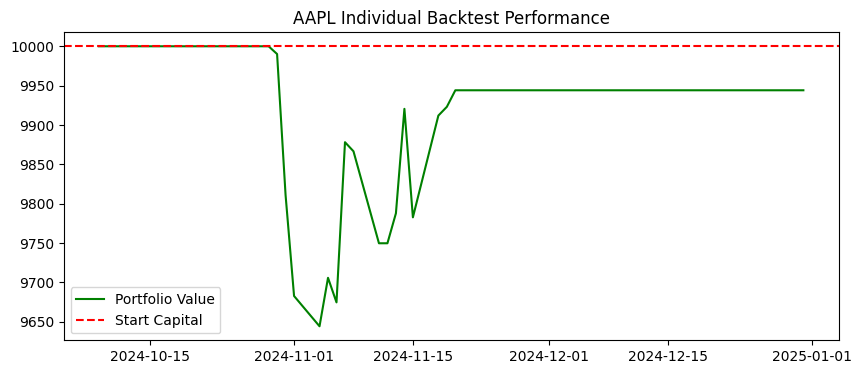


 PROCESSING: MSFT
  > Training ARIMA model...
  > Running Backtest...


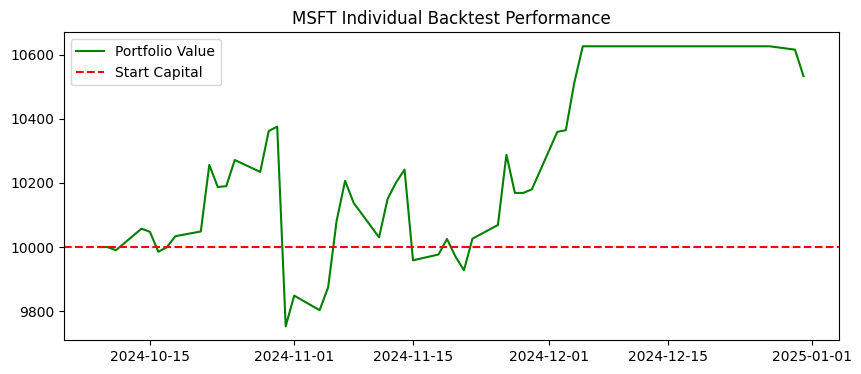




PORTFOLIO EVALUATION REPORT

INDIVIDUAL STOCK PERFORMANCE:
--------------------------------------------------------------------------------
Stock    Model           Return%      Sharpe     MaxDD%     WinRate%   PF        
--------------------------------------------------------------------------------
AAPL     ARIMA (1,1,1)       -0.56%     -0.03     -3.56%     0.00%     0.00
MSFT     ARIMA (1,1,1)        5.33%      0.08     -6.00%   100.00%      inf
--------------------------------------------------------------------------------

Initial Capital:       $10,000.00
Final Portfolio Value: $10,238.43
Total Profit:          $238.43
Total Return:          2.38%
Sharpe Ratio:          0.05
Maximum Drawdown:      -4.51%
Volatility:            0.75%


In [30]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from backtest import Backtest
from utils import PortfolioEvaluator
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# CONFIGURATION
# ==========================================
MY_STOCKS = ['AAPL', 'MSFT']
START_DATE = '2022-01-01'
END_DATE = '2025-01-01'
TEST_DAYS = 60
SEASONAL_PERIOD = 252

# Initialize the Portfolio Evaluator (Manages the $10k capital)
# We assume equal weighting (50% AAPL, 50% MSFT) for the final report
portfolio = PortfolioEvaluator(starting_capital=10000, allocation="equal")

def get_data(ticker):
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df = df.xs(ticker, axis=1, level=1)
    df = df.asfreq('B').ffill()
    return df[['Close']]

def process_stock(ticker):
    print(f"\n{'='*40}\n PROCESSING: {ticker}\n{'='*40}")
    
    # 1. Data Prep
    df = get_data(ticker)
    series = df['Close']
    
    # 2. Decomposition (Old Attempt Logic)
    decomp = seasonal_decompose(series, model='additive', period=SEASONAL_PERIOD)
    seasonal = decomp.seasonal
    sa_series = series - seasonal
    
    # 3. Split Data (Training vs Internal Test)
    split_idx = len(sa_series) - TEST_DAYS
    
    train_sa = sa_series.iloc[:split_idx]
    
    # 4. Train Model
    # We use the "Old Attempt" ARIMA logic that worked well for you
    print("  > Training ARIMA model...")
    model = ARIMA(train_sa, order=(1,1,1)).fit()
    
    # 5. Generate PREDICTIONS for the TEST SET
    # This is crucial: We need predictions that overlap with known history
    pred_sa = model.forecast(steps=TEST_DAYS)
    
    # Reconstruct: SA_Forecast + Test_Seasonality
    test_seasonal = seasonal.iloc[split_idx:]
    predicted_prices = pred_sa.values + test_seasonal.values
    
    # Get ACTUAL prices for the same period
    actual_prices = series.iloc[split_idx:]
    
    # 6. BACKTESTING
    print("  > Running Backtest...")
    # We run a backtest for this specific stock
    # Note: We pass the aligned Series so dates match
    backtester = Backtest(starting_capital=10000) 
    
    # Run the default strategy provided in the PDF instructions
    # (Buy if Predict > Actual + Threshold)
    backtester.run_strategy(actual_prices, pd.Series(predicted_prices, index=actual_prices.index))
    
    # 7. Add to Portfolio
    # The PortfolioEvaluator will handle the weighting (e.g., allocating $5k to this)
    portfolio.add_stock(ticker, backtester, "ARIMA (1,1,1)")
    
    # 8. Visualization
    plt.figure(figsize=(10, 4))
    plt.plot(actual_prices.index, backtester.portfolio_values, label='Portfolio Value', color='green')
    plt.axhline(y=10000, color='red', linestyle='--', label='Start Capital')
    plt.title(f"{ticker} Individual Backtest Performance")
    plt.legend()
    plt.show()

# --- RUN ANALYSIS ---
for stock in MY_STOCKS:
    process_stock(stock)

# --- FINAL REPORT ---
print("\n\n")
portfolio.show_report()

# Testing pipeline

In [32]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize

# Custom modules (ensure these files are in the same directory)
from backtest import Backtest
from utils import PortfolioEvaluator, TradingMetrics, ForecastingMetrics

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# CASE CONSTRAINTS & CONFIG
# ==========================================
MY_STOCKS = ['AAPL', 'MSFT'] # Add more if you want a bigger portfolio
START_DATE = '2022-01-01'
END_DATE = '2025-01-01'      # Strict end date per PDF
FORECAST_DAYS = 60           # The "random 60-day period" task
SEASONAL_PERIOD = 252        # Trading days in a year
LAGS = 60                    # Lookback window for ML models
CAPITAL = 10000              # Starting capital per PDF

print("Environment Setup Complete.")

Environment Setup Complete.


In [33]:
def get_data(ticker):
    print(f"Fetching data for {ticker}...")
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
    
    # Handle MultiIndex columns if yfinance returns them
    if isinstance(df.columns, pd.MultiIndex):
        df = df.xs(ticker, axis=1, level=1)
        
    # Enforce Business Day frequency to avoid gaps on weekends
    df = df.asfreq('B')
    df['Close'] = df['Close'].ffill() # Fill holidays with previous price
    return df[['Close']]

# Store data for all stocks
stock_data = {ticker: get_data(ticker) for ticker in MY_STOCKS}
print("\nData loaded successfully.")

Fetching data for AAPL...
Fetching data for MSFT...

Data loaded successfully.


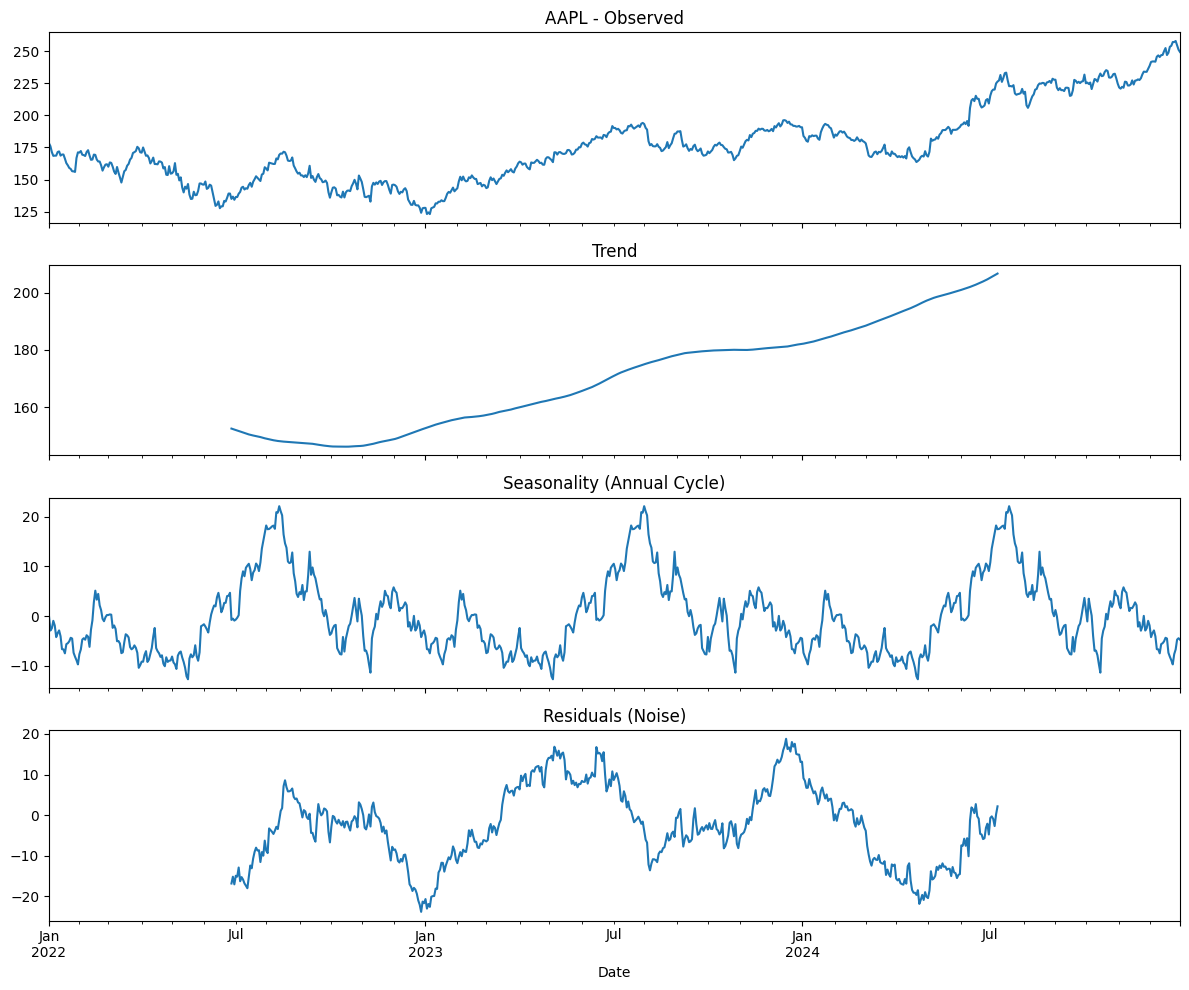


--- Stationarity Tests for AAPL Residuals ---
ADF p-value:  0.0476 (Stationary)
KPSS p-value: 0.1000 (Stationary)


In [34]:
def diagnose_stock(ticker, df):
    series = df['Close']
    
    # 1. Decompose to visualize components
    # We use additive: Price = Trend + Seasonal + Residual
    decomp = seasonal_decompose(series, model='additive', period=SEASONAL_PERIOD)
    
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    decomp.observed.plot(ax=axes[0], title=f'{ticker} - Observed')
    decomp.trend.plot(ax=axes[1], title='Trend')
    decomp.seasonal.plot(ax=axes[2], title='Seasonality (Annual Cycle)')
    decomp.resid.plot(ax=axes[3], title='Residuals (Noise)')
    plt.tight_layout()
    plt.show()
    
    # 2. Stationarity Tests on Residuals
    # We model residuals because they are usually stationary (easier to predict)
    resid = decomp.resid.dropna()
    
    print(f"\n--- Stationarity Tests for {ticker} Residuals ---")
    # ADF Test (p < 0.05 means Stationary)
    adf_p = adfuller(resid)[1]
    print(f"ADF p-value:  {adf_p:.4f} ({'Stationary' if adf_p < 0.05 else 'Non-Stationary'})")
    
    # KPSS Test (p > 0.05 means Stationary)
    kpss_p = kpss(resid, regression='c', nlags="auto")[1]
    print(f"KPSS p-value: {kpss_p:.4f} ({'Stationary' if kpss_p > 0.05 else 'Non-Stationary'})")

# Run diagnostics for one stock to demonstrate
diagnose_stock('AAPL', stock_data['AAPL'])

In [35]:
def make_lagged(series, nlags):
    """Creates features (X) and target (y) for ML models."""
    s = pd.Series(series).reset_index(drop=True)
    df = pd.DataFrame({'y': s})
    for i in range(1, nlags+1):
        df[f'lag_{i}'] = s.shift(i)
    return df.dropna()

def recursive_forecast(last_window, model, steps, feature_names):
    """Recursively predicts future values for ML models."""
    preds = []
    current_window = list(last_window)
    for _ in range(steps):
        input_df = pd.DataFrame([current_window], columns=feature_names)
        pred = model.predict(input_df)[0]
        preds.append(pred)
        current_window.pop(0)
        current_window.append(pred)
    return np.array(preds)

def train_and_validate(ticker, df):
    print(f"\n=== Training Models for {ticker} ===")
    series = df['Close']
    
    # 1. Decompose
    decomp = seasonal_decompose(series, model='additive', period=SEASONAL_PERIOD)
    seasonal = decomp.seasonal
    sa_series = series - seasonal # Seasonally Adjusted
    
    # 2. Split (Validate on last 60 days)
    split_idx = len(sa_series) - FORECAST_DAYS
    train_sa = sa_series.iloc[:split_idx]
    test_sa = sa_series.iloc[split_idx:]
    test_seasonal = seasonal.iloc[split_idx:]
    
    # 3. Prepare ML Data
    df_lagged = make_lagged(sa_series, LAGS)
    X = df_lagged.drop(columns='y')
    y = df_lagged['y']
    
    # Align ML split with ARIMA split
    train_size = split_idx - LAGS
    X_train, X_test = X.iloc[:train_size], X.iloc[train_size:train_size+FORECAST_DAYS]
    y_train, y_test = y.iloc[:train_size], y.iloc[train_size:train_size+FORECAST_DAYS]

    # 4. Train & Predict
    preds = {}
    
    # ARIMA
    arima = ARIMA(train_sa, order=(1,1,1)).fit()
    p_arima = arima.forecast(steps=FORECAST_DAYS)
    preds['ARIMA'] = p_arima.values + test_seasonal.values
    
    # Linear Regression
    lr = LinearRegression().fit(X_train, y_train)
    p_lr = recursive_forecast(train_sa.iloc[-LAGS:].values, lr, FORECAST_DAYS, X_train.columns)
    preds['LinReg'] = p_lr + test_seasonal.values
    
    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42).fit(X_train, y_train)
    p_rf = recursive_forecast(train_sa.iloc[-LAGS:].values, rf, FORECAST_DAYS, X_train.columns)
    preds['RF'] = p_rf + test_seasonal.values
    
    # 5. Evaluate Accuracy
    actual = series.iloc[split_idx:].values
    scores = {k: mean_squared_error(actual, v) for k, v in preds.items()}
    winner = min(scores, key=scores.get)
    
    print(f"  > Validation MSE: {scores}")
    print(f"  > Best Model: {winner}")
    
    # Return everything needed for next steps
    return {
        'winner': winner,
        'models': {'ARIMA': arima, 'LinReg': lr, 'RF': rf},
        'data': {'X': X, 'y': y, 'sa': sa_series, 'seasonal': seasonal},
        'preds': preds,
        'actual': actual,
        'test_index': series.index[split_idx:]
    }

# Store results
results = {}
for stock in MY_STOCKS:
    results[stock] = train_and_validate(stock, stock_data[stock])


=== Training Models for AAPL ===
  > Validation MSE: {'ARIMA': 308.3264616025803, 'LinReg': 568.0975924635649, 'RF': 331.2251576505582}
  > Best Model: ARIMA

=== Training Models for MSFT ===
  > Validation MSE: {'ARIMA': 345.5904707581102, 'LinReg': 237.03101483141342, 'RF': 190.6679920679802}
  > Best Model: RF


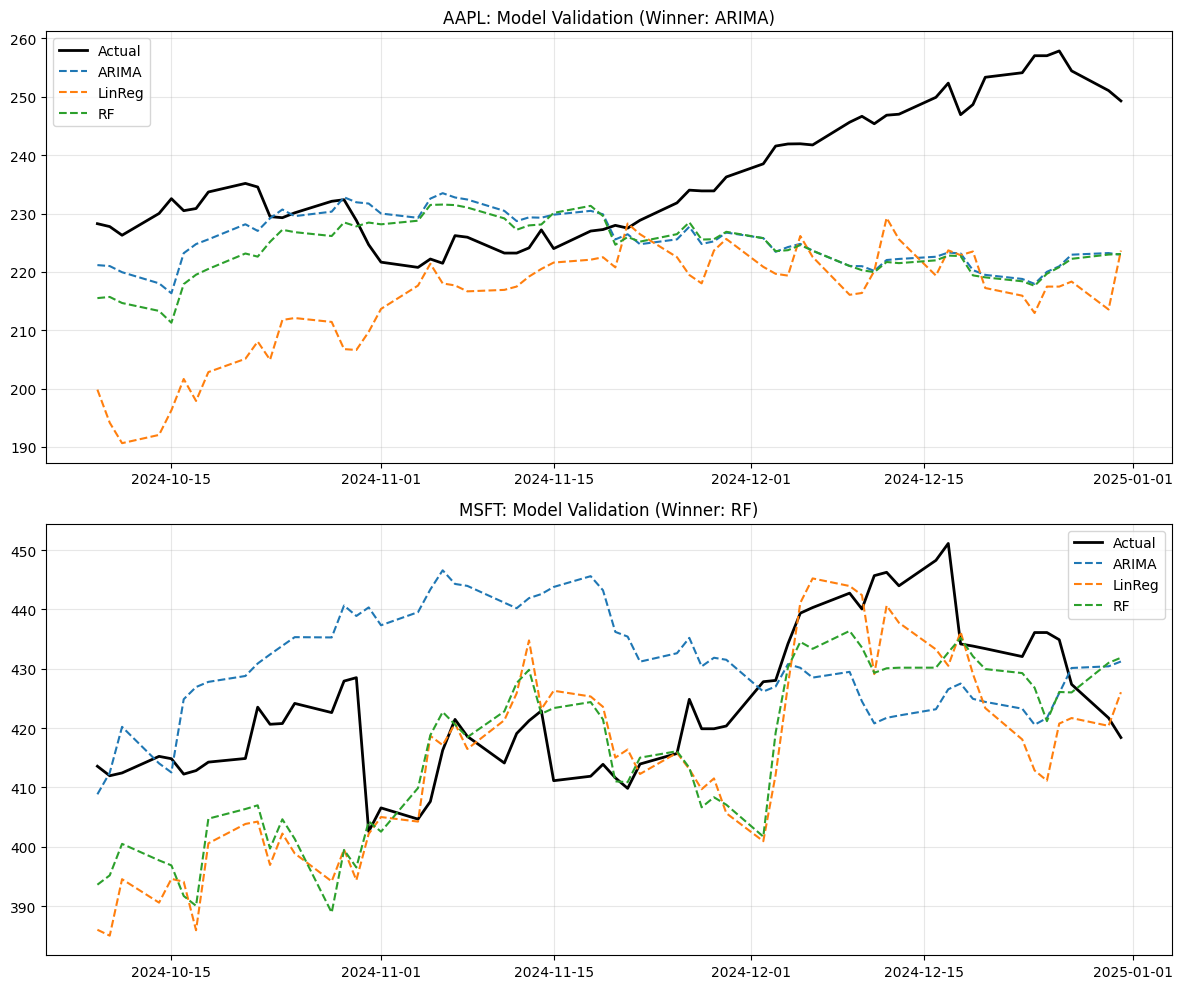

In [36]:
fig, axes = plt.subplots(len(MY_STOCKS), 1, figsize=(12, 5 * len(MY_STOCKS)))
if len(MY_STOCKS) == 1: axes = [axes]

for ax, stock in zip(axes, MY_STOCKS):
    res = results[stock]
    idx = res['test_index']
    
    ax.plot(idx, res['actual'], label='Actual', color='black', linewidth=2)
    for name, p in res['preds'].items():
        ax.plot(idx, p, label=name, linestyle='--')
        
    ax.set_title(f"{stock}: Model Validation (Winner: {res['winner']})")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
print("=== PROFITABILITY CHECK (VALIDATION PERIOD) ===")

backtest_results = {}

for stock in MY_STOCKS:
    res = results[stock]
    # Get the prediction array of the winning model
    best_pred = res['preds'][res['winner']]
    
    # Initialize Backtester with $10k
    bt = Backtest(starting_capital=CAPITAL)
    
    # Run Strategy: Pass ALIGNED series (same dates)
    # Strategy: Buy if Predict > Actual + 1%
    actual_series = pd.Series(res['actual'], index=res['test_index'])
    pred_series = pd.Series(best_pred, index=res['test_index'])
    
    bt.run_strategy(actual_series, pred_series)
    metrics = bt.compute_trade_metrics()
    
    backtest_results[stock] = {
        'metrics': metrics,
        'equity_curve': bt.portfolio_values,
        'backtester': bt # Save for portfolio optimization
    }
    
    print(f"\n{stock} ({res['winner']}):")
    print(f"  ROI: {metrics['Cumulative Return']:.2f}%")
    print(f"  Sharpe: {metrics['Sharpe Ratio']:.2f}")
    print(f"  Drawdown: {metrics['Max Drawdown']:.2f}%")

=== PROFITABILITY CHECK (VALIDATION PERIOD) ===

AAPL (ARIMA):
  ROI: -0.56%
  Sharpe: -0.03
  Drawdown: -3.56%

MSFT (RF):
  ROI: 3.75%
  Sharpe: 0.09
  Drawdown: -3.01%


=== MARKOWITZ PORTFOLIO OPTIMIZATION ===

[Static] Optimal Weights (based on past year):
  AAPL: 43.9%
  MSFT: 56.1%

[Dynamic] Running rolling optimization (Window=60)...


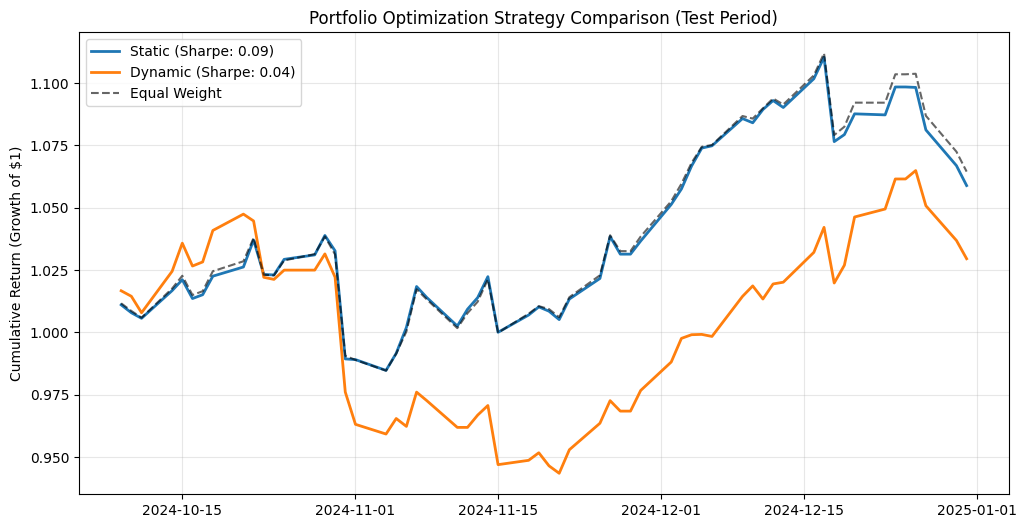

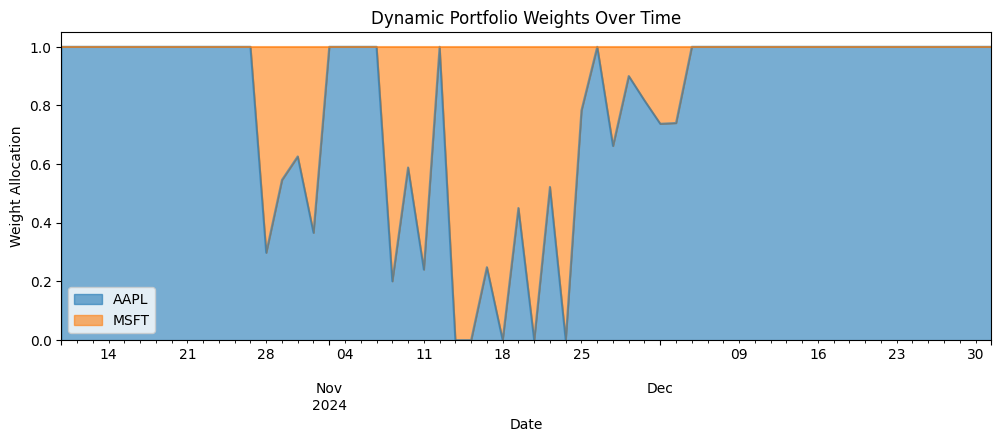

In [43]:
import scipy.optimize as sco
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import TradingMetrics # Ensure this import is present

print("=== MARKOWITZ PORTFOLIO OPTIMIZATION ===")

# 1. PREPARE DATA (Returns)
all_returns = pd.DataFrame()
for stock in MY_STOCKS:
    # Get full available history and calculate daily returns
    # Note: stock_data dictionary must be populated from previous steps
    full_price = stock_data[stock]['Close']
    all_returns[stock] = full_price.pct_change().dropna()

# Define Periods
test_returns = all_returns.iloc[-FORECAST_DAYS:]
train_returns = all_returns.iloc[:-FORECAST_DAYS]

# 2. OPTIMIZATION ENGINE
def get_portfolio_metrics(weights, returns):
    """Calculates portfolio return, volatility, and Sharpe."""
    weights = np.array(weights)
    # Annualized metrics (assuming 252 trading days)
    port_ret = np.sum(returns.mean() * weights) * 252
    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))
    sharpe = port_ret / port_vol if port_vol > 0 else 0
    return port_ret, port_vol, sharpe

def maximize_sharpe(returns_data):
    """Finds weights that maximize Sharpe Ratio."""
    num_assets = len(returns_data.columns)
    
    # Arguments to pass to the objective function
    args = (returns_data,)
    
    # Objective: Minimize Negative Sharpe
    # FIXED: Added 'returns' argument to accept the passed args
    def neg_sharpe(weights, returns):
        return -get_portfolio_metrics(weights, returns)[2]
    
    # Constraints: Weights sum to 1, 0 <= weight <= 1 (No shorting)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0.0, 1.0) for asset in range(num_assets))
    init_guess = [1./num_assets for _ in range(num_assets)]
    
    result = sco.minimize(neg_sharpe, init_guess, args=args, 
                          method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

# 3. STRATEGY A: STATIC OPTIMIZATION
# Optimize ONCE using past 1 year of data
lookback_static = 252 
static_train_data = train_returns.iloc[-lookback_static:]

static_weights = maximize_sharpe(static_train_data)
static_w_dict = dict(zip(MY_STOCKS, static_weights))

print("\n[Static] Optimal Weights (based on past year):")
for s, w in static_w_dict.items(): print(f"  {s}: {w*100:.1f}%")

# Calculate Static Performance
static_portfolio_daily = (test_returns * static_weights).sum(axis=1)
static_cum_ret = (1 + static_portfolio_daily).cumprod()

# 4. STRATEGY B: DYNAMIC OPTIMIZATION (Rolling)
dynamic_window = 60 
dynamic_portfolio_daily = []
dynamic_weights_history = []

print(f"\n[Dynamic] Running rolling optimization (Window={dynamic_window})...")

# Concatenate end of train + test to simulate rolling window
rolling_data = pd.concat([train_returns.iloc[-dynamic_window:], test_returns])

for t in range(len(test_returns)):
    # Window leading up to today
    window_returns = rolling_data.iloc[t : t + dynamic_window]
    
    # Optimize on this window
    d_weights = maximize_sharpe(window_returns)
    
    # Apply weights to TODAY'S return
    today_ret = np.dot(test_returns.iloc[t].values, d_weights)
    
    dynamic_portfolio_daily.append(today_ret)
    dynamic_weights_history.append(d_weights)

dynamic_cum_ret = (1 + pd.Series(dynamic_portfolio_daily, index=test_returns.index)).cumprod()

# 5. BENCHMARK: EQUAL WEIGHT
equal_weights = np.array([1/len(MY_STOCKS)] * len(MY_STOCKS))
equal_portfolio_daily = (test_returns * equal_weights).sum(axis=1)
equal_cum_ret = (1 + equal_portfolio_daily).cumprod()

# 6. VISUALIZATION
plt.figure(figsize=(12, 6))
plt.plot(static_cum_ret.index, static_cum_ret, label=f"Static (Sharpe: {TradingMetrics.sharpe_ratio(static_portfolio_daily):.2f})", linewidth=2)
plt.plot(dynamic_cum_ret.index, dynamic_cum_ret, label=f"Dynamic (Sharpe: {TradingMetrics.sharpe_ratio(dynamic_portfolio_daily):.2f})", linewidth=2)
plt.plot(equal_cum_ret.index, equal_cum_ret, label=f"Equal Weight", linestyle='--', color='black', alpha=0.6)

plt.title("Portfolio Optimization Strategy Comparison (Test Period)")
plt.ylabel("Cumulative Return (Growth of $1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. ALLOCATION PLOT
weights_df = pd.DataFrame(dynamic_weights_history, index=test_returns.index, columns=MY_STOCKS)
weights_df.plot.area(figsize=(12, 4), alpha=0.6, title="Dynamic Portfolio Weights Over Time")
plt.ylabel("Weight Allocation")
plt.show()

In [44]:
# 1. Generate Future Forecasts (Next 60 Days) using the Winners
future_dates = pd.date_range(start=pd.to_datetime(END_DATE) + pd.Timedelta(days=1), 
                             periods=FORECAST_DAYS, freq='B')

for stock in MY_STOCKS:
    res = results[stock]
    winner = res['winner']
    
    # Prepare full data
    sa_full = res['data']['sa']
    season_full = res['data']['seasonal']
    
    # Future Seasonality (Tile last cycle)
    future_season = np.tile(season_full.iloc[-SEASONAL_PERIOD:].values, 2)[:FORECAST_DAYS]
    
    future_vals = []
    
    if winner == 'ARIMA':
        # Refit ARIMA
        model = ARIMA(sa_full, order=(1,1,1)).fit()
        future_vals = model.forecast(FORECAST_DAYS).values
    else:
        # Refit ML
        model = res['models'][winner] # Already trained instance, or refit here
        # Note: Ideally refit on *all* data, but for simplicity we use the trained one
        # Recurse from last window
        X_full = make_lagged(sa_full, LAGS).drop(columns='y')
        last_window = sa_full.iloc[-LAGS:].values
        feature_names = X_full.columns
        future_vals = recursive_forecast(last_window, model, FORECAST_DAYS, feature_names)
        
    # Reconstruct
    final_prices = future_vals + future_season
    
    # Save
    df_out = pd.DataFrame({'Date': future_dates, 'Close': final_prices}).set_index('Date')
    df_out.to_csv(f"{stock}_forecasts.csv")
    stock_data[stock].to_csv(f"{stock}_historical.csv")
    print(f"Saved forecasts for {stock} using {winner}")

# 2. Final Portfolio Report
evaluator = PortfolioEvaluator(starting_capital=CAPITAL, allocation=optimal_weights)
# Register stocks (using the backtesters we already ran)
for stock in MY_STOCKS:
    evaluator.add_stock(stock, backtest_results[stock]['backtester'], results[stock]['winner'])

evaluator.show_report()

Saved forecasts for AAPL using ARIMA
Saved forecasts for MSFT using RF
PORTFOLIO EVALUATION REPORT

INDIVIDUAL STOCK PERFORMANCE:
--------------------------------------------------------------------------------
Stock    Model           Return%      Sharpe     MaxDD%     WinRate%   PF        
--------------------------------------------------------------------------------
AAPL     ARIMA               -0.56%     -0.03     -3.56%     0.00%     0.00
MSFT     RF                   3.75%      0.09     -3.01%   100.00%      inf
--------------------------------------------------------------------------------

Initial Capital:       $10,000.00
Final Portfolio Value: $10,375.36
Total Profit:          $375.36
Total Return:          3.75%
Sharpe Ratio:          0.09
Maximum Drawdown:      -3.01%
Volatility:            0.63%
